# KMeans\+\+ con Distancia Euclidiana

In [1]:
import os
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score

In [2]:
class KMeansPP:
    def __init__(self, n_clusters=5, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None

    def initialize_centroids(self, X):
        random.seed(self.random_state)
        n_samples = len(X)
        centroids = [X[random.randint(0, n_samples - 1)]]

        for _ in range(1, self.n_clusters):
            distances = np.array([min(np.linalg.norm(x - c)**2 for c in centroids) for x in X])
            probs = distances / distances.sum()
            cumulative_probs = np.cumsum(probs)
            r = random.random()
            for i, p in enumerate(cumulative_probs):
                if r < p:
                    centroids.append(X[i])
                    break
        return np.array(centroids)

    def assign_clusters(self, X):
        labels = []
        for x in X:
            distances = [np.linalg.norm(x - c) for c in self.centroids]
            labels.append(np.argmin(distances))
        return np.array(labels)

    def update_centroids(self, X, labels):
        new_centroids = []
        for i in range(self.n_clusters):
            points = X[labels == i]
            if len(points) > 0:
                new_centroids.append(np.mean(points, axis=0))
            else:
                new_centroids.append(X[random.randint(0, len(X)-1)])
        return np.array(new_centroids)

    def fit(self, X):
        X = np.array(X)
        self.centroids = self.initialize_centroids(X)

        for iteration in range(self.max_iter):
            labels = self.assign_clusters(X)
            new_centroids = self.update_centroids(X, labels)
            shift = np.sum([np.linalg.norm(a - b) for a, b in zip(self.centroids, new_centroids)])
            if shift < self.tol:
                break
            self.centroids = new_centroids

        self.labels_ = labels
        self.inertia_ = np.sum([np.linalg.norm(X[i] - self.centroids[labels[i]])**2 for i in range(len(X))])
        return labels

In [3]:
def find_optimal_k(X, name, output_dir, max_k=15, random_state=42):
    inertias, silhouettes = [], []
    ks = list(range(2, max_k + 1))

    for k in ks:
        model = KMeansPP(n_clusters=k, random_state=random_state)
        labels = model.fit(X)
        inertias.append(model.inertia_)
        silhouettes.append(silhouette_score(X, labels))

    # Graficar ambos métodos
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(ks, inertias, marker='o')
    plt.title("Método del Codo")
    plt.xlabel("Número de clusters (k)")
    plt.ylabel("Inercia")

    plt.subplot(1, 2, 2)
    plt.plot(ks, silhouettes, marker='o', color='orange')
    plt.title("Silhouette promedio")
    plt.xlabel("Número de clusters (k)")
    plt.ylabel("Silhouette Score")

    plt.tight_layout()
    fig_path = os.path.join(output_dir, f"comparativa_{name}.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

    best_k = ks[int(np.argmax(silhouettes))]
    print(f"Mejor número de clusters según Silhouette: k = {best_k}")
    return best_k, silhouettes, inertias

In [4]:
def process_and_cluster(file_path, name, output_dir, n_clusters=None):
    print(f"\n>>> Procesando dataset: {name}")

    df = pd.read_csv(file_path)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)

    # Detectar si es 2D o 3D automáticamente
    coord_cols = ['UMAP1', 'UMAP2'] if 'UMAP3' not in df.columns else ['UMAP1', 'UMAP2', 'UMAP3']
    X = df[coord_cols].values
    movie_ids = df['movieId'].values

    # Determinar k óptimo
    if n_clusters is None:
        n_clusters, _, _ = find_optimal_k(X, name, output_dir)

    # Entrenar modelo final
    model = KMeansPP(n_clusters=n_clusters)
    labels = model.fit(X)
    sil = silhouette_score(X, labels)
    print(f"Silhouette final ({name}): {sil:.4f}")

    # Crear DataFrame con resultados
    results = df[['movieId'] + coord_cols].copy()
    results['cluster'] = labels

    # Guardar CSV
    output_csv = os.path.join(output_dir, f"kmeanspp_clustered_{name}.csv")
    results.to_csv(output_csv, index=False)
    print(f"Archivo CSV guardado: {output_csv}")

    # Graficar clusters en 2D o 3D
    if len(coord_cols) == 2:
        plt.figure(figsize=(7,6))
        plt.scatter(df['UMAP1'], df['UMAP2'], c=labels, cmap='tab10', s=25, alpha=0.8)
        plt.title(f"Clusters UMAP 2D - {name}")
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"clusters_2D_{name}.png"), dpi=200)
        plt.show()
    else:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(df['UMAP1'], df['UMAP2'], df['UMAP3'], c=labels, cmap='tab10', s=25)
        ax.set_title(f"Clusters UMAP 3D - {name}")
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")
        ax.set_zlabel("UMAP3")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"clusters_3D_{name}.png"), dpi=200)
        plt.show()

    return results, sil, n_clusters


>>> Procesando dataset: nmf_umap_2d


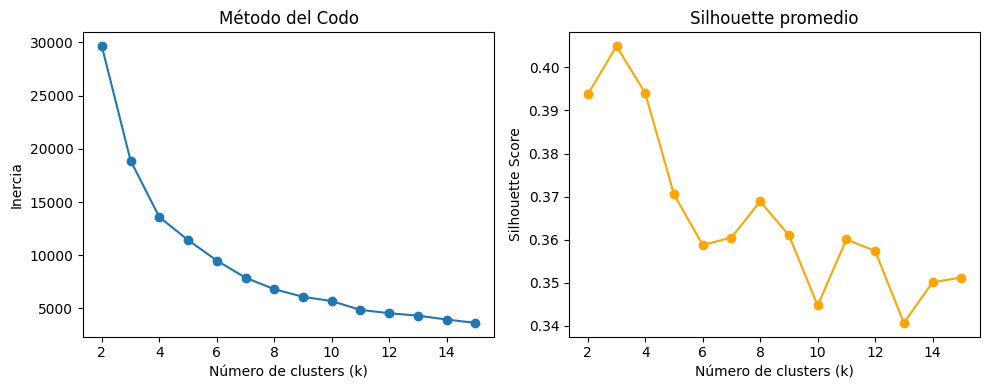

Mejor número de clusters según Silhouette: k = 3
Silhouette final (nmf_umap_2d): 0.4049
Archivo CSV guardado: /work/Punto5/KMeansPP/kmeanspp_clustered_nmf_umap_2d.csv


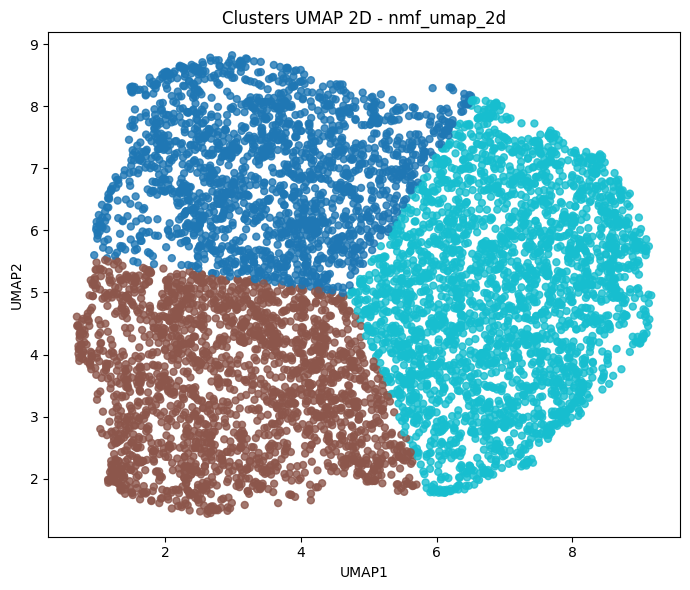


>>> Procesando dataset: nmf_umap_3d


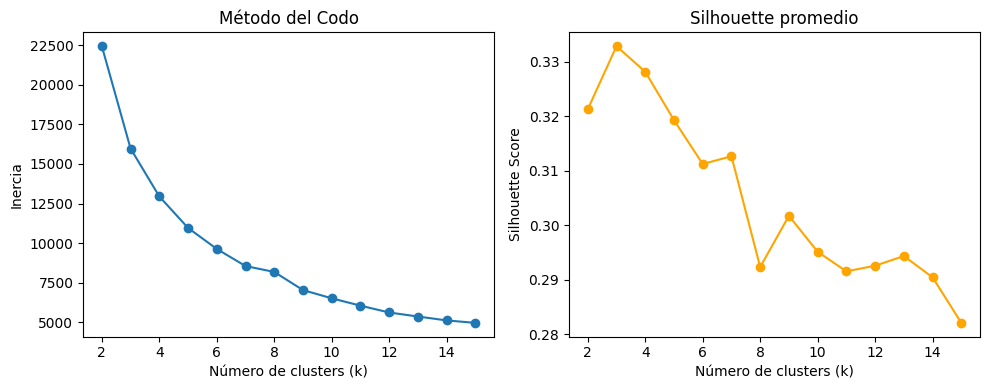

Mejor número de clusters según Silhouette: k = 3
Silhouette final (nmf_umap_3d): 0.3328
Archivo CSV guardado: /work/Punto5/KMeansPP/kmeanspp_clustered_nmf_umap_3d.csv


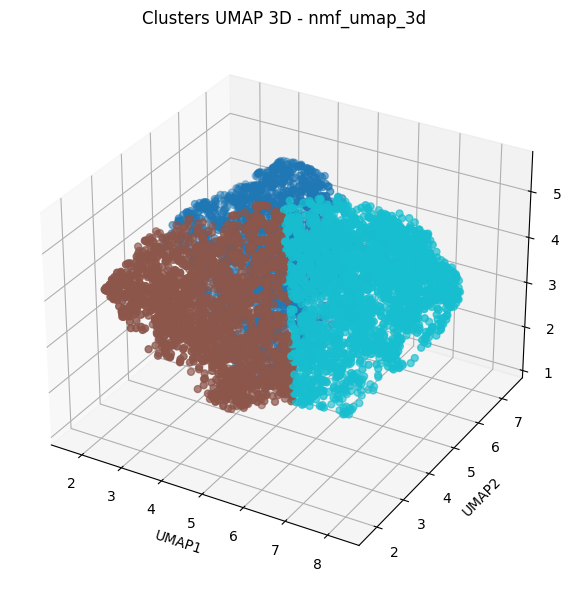


>>> Procesando dataset: pca_umap_2d


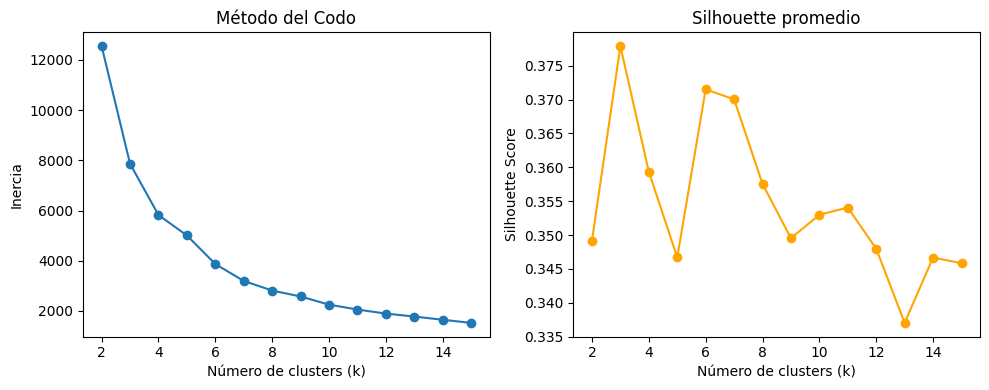

Mejor número de clusters según Silhouette: k = 3
Silhouette final (pca_umap_2d): 0.3779
Archivo CSV guardado: /work/Punto5/KMeansPP/kmeanspp_clustered_pca_umap_2d.csv


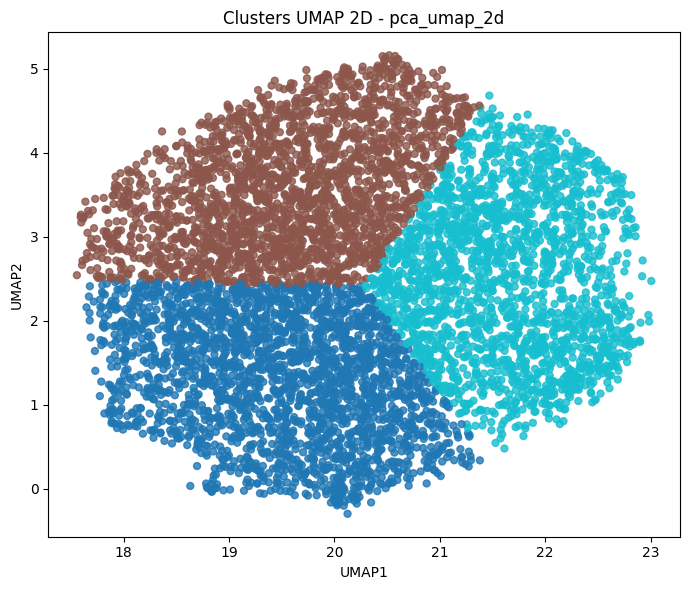


>>> Procesando dataset: pca_umap_3d


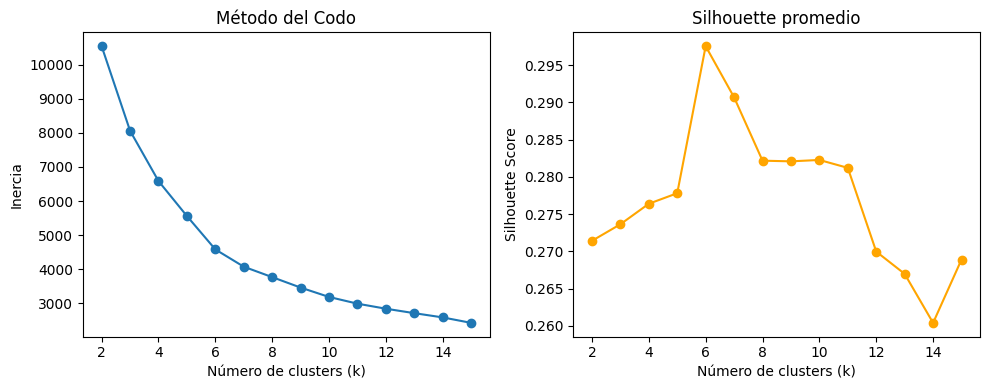

Mejor número de clusters según Silhouette: k = 6
Silhouette final (pca_umap_3d): 0.2976
Archivo CSV guardado: /work/Punto5/KMeansPP/kmeanspp_clustered_pca_umap_3d.csv


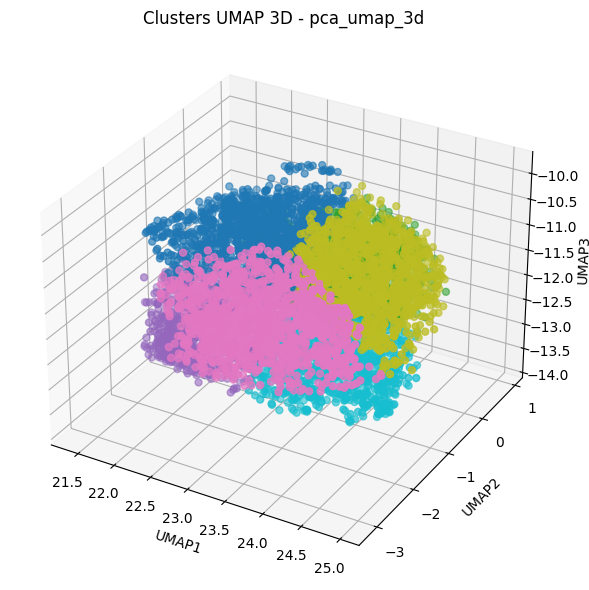

In [5]:
# Directorio de salida
output_dir = "/work/Punto5/KMeansPP"
os.makedirs(output_dir, exist_ok=True)

# Archivos de entrada
datasets = [
    ("/work/Punto4/nmf+umap/nmf_umap_2d.csv", "nmf_umap_2d"),
    ("/work/Punto4/nmf+umap/nmf_umap_3d.csv", "nmf_umap_3d"),
    ("/work/Punto4/pca+umap/pca_umap_2d.csv", "pca_umap_2d"),
    ("/work/Punto4/pca+umap/pca_umap_3d.csv", "pca_umap_3d")
]

# Procesamiento de todos los datasets
silhouette_scores = {}
for path, name in datasets:
    try:
        results, sil, k = process_and_cluster(path, name, output_dir)
        silhouette_scores[name] = sil
    except Exception as e:
        print(f"Error procesando {name}: {e}")

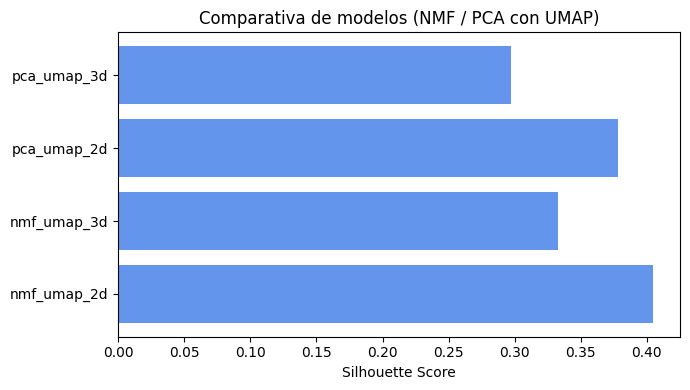


📋 Resumen de Silhouette:
 - nmf_umap_2d: 0.4049
 - nmf_umap_3d: 0.3328
 - pca_umap_2d: 0.3779
 - pca_umap_3d: 0.2976


In [6]:
plt.figure(figsize=(7,4))
plt.barh(list(silhouette_scores.keys()), list(silhouette_scores.values()), color='cornflowerblue')
plt.xlabel("Silhouette Score")
plt.title("Comparativa de modelos (NMF / PCA con UMAP)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "comparativa_silhouette_global.png"), dpi=200)
plt.show()

print("\n📋 Resumen de Silhouette:")
for name, sil in silhouette_scores.items():
    print(f" - {name}: {sil:.4f}")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=00a7e178-dbb4-487e-9ec4-c9816530a68a' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>